✅ Loaded 400 images from 40 people
🚀 Training model...


/home/student/0019/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model Accuracy: 47.50%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

🔹 Predicted: Person 38
🔹 Actual:    Person 38


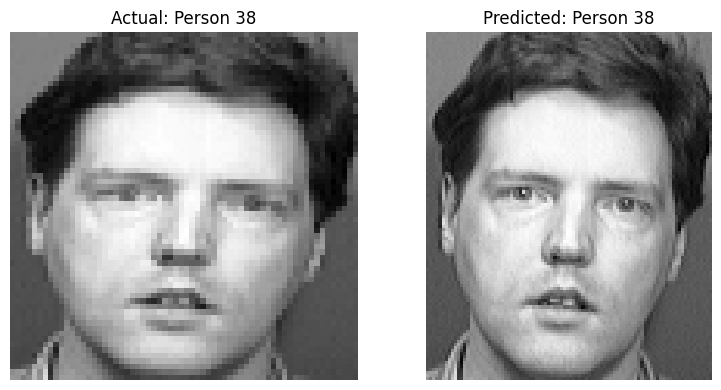

In [10]:
# -----------------------------
# 📦 Imports
# -----------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -----------------------------
# 📂 Load Dataset
# -----------------------------
path = "/home/student/.cache/kagglehub/datasets/kasikrit/att-database-of-faces/versions/2"

# ✅ Sort folders numerically (avoids mismatch)
people = sorted(
    [p for p in os.listdir(path) if p.startswith('s')],
    key=lambda x: int(x[1:])
)

images, labels = [], []

for idx, person in enumerate(people):
    folder = os.path.join(path, person)
    for file in os.listdir(folder):
        if file.endswith(".pgm"):
            img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            images.append(img.flatten())
            labels.append(idx)

images = np.array(images)
labels = np.array(labels)

print(f"✅ Loaded {len(images)} images from {len(people)} people")

# -----------------------------
# 🧩 Split Data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# -----------------------------
# 🎯 Preprocess
# -----------------------------
X_train = X_train / 255.0
X_test = X_test / 255.0
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# -----------------------------
# 🧠 Build ANN Model
# -----------------------------
model = Sequential([
    Dense(512, activation='relu', input_shape=(4096,)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(len(people), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training model...")
model.fit(X_train, y_train_cat, epochs=40, batch_size=16, validation_split=0.1, verbose=0)

# -----------------------------
# 📊 Evaluate
# -----------------------------
acc = model.evaluate(X_test, y_test_cat, verbose=0)[1] * 100
print(f"✅ Model Accuracy: {acc:.2f}%")

# -----------------------------
# 🎲 Pick Random Test Image
# -----------------------------
idx = np.random.randint(0, len(X_test))
test_img = X_test[idx]
true_label = y_test[idx]
pred_label = np.argmax(model.predict(test_img.reshape(1, -1)))

print(f"\n🔹 Predicted: Person {pred_label + 1}")
print(f"🔹 Actual:    Person {true_label + 1}")

# -----------------------------
# 🖼️ Display Both Images
# -----------------------------
plt.figure(figsize=(8,4))

# Actual test image
plt.subplot(1,2,1)
plt.imshow(test_img.reshape(64,64), cmap='gray')
plt.title(f"Actual: Person {true_label + 1}")
plt.axis('off')

# Predicted person's image (first image from their folder)
pred_folder = os.path.join(path, f"s{pred_label+1}")
pred_img_path = os.path.join(pred_folder, os.listdir(pred_folder)[0])
pred_img = cv2.imread(pred_img_path, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,2,2)
plt.imshow(pred_img, cmap='gray')
plt.title(f"Predicted: Person {pred_label + 1}")
plt.axis('off')

plt.tight_layout()
plt.show()


✅ Loaded 400 images of 40 persons
🚀 Training Model...


/home/student/0019/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0069 - loss: 4.5436 - val_accuracy: 0.0000e+00 - val_loss: 3.8394
Epoch 2/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0139 - loss: 3.8812 - val_accuracy: 0.0312 - val_loss: 3.7259
Epoch 3/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.0104 - loss: 3.7551 - val_accuracy: 0.0000e+00 - val_loss: 3.6962
Epoch 4/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.0312 - loss: 3.6843 - val_accuracy: 0.0625 - val_loss: 3.6873
Epoch 5/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0382 - loss: 3.7115 - val_accuracy: 0.0312 - val_loss: 3.6689
Epoch 6/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0486 - loss: 3.6621 - val_accuracy: 0.0312 - val_loss: 3.6416
Epoch 7/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0625 - loss: 3.6262 - val_accuracy: 0.0625 - val_loss: 3.6688
Epoch 8/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0382 - loss: 3.6069 - val_accuracy: 0.

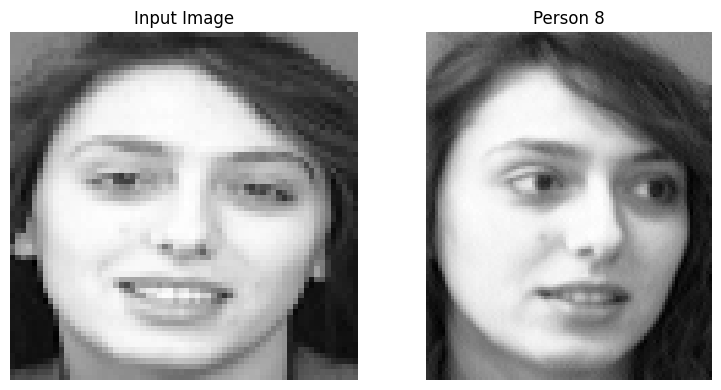

In [11]:
# -----------------------------
# 📦 Imports
# -----------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -----------------------------
# 📂 Load Dataset
# -----------------------------
path = "/home/student/.cache/kagglehub/datasets/kasikrit/att-database-of-faces/versions/2"

# Sort s1, s2, s3, ..., s40 correctly
people = sorted(
    [p for p in os.listdir(path) if p.startswith('s')],
    key=lambda x: int(x[1:])
)

images, labels = [], []
for idx, person in enumerate(people):
    folder = os.path.join(path, person)
    for file in os.listdir(folder):
        if file.endswith(".pgm"):
            img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            images.append(img.flatten())
            labels.append(idx)

images = np.array(images)
labels = np.array(labels)

print(f"✅ Loaded {len(images)} images of {len(people)} persons")

# -----------------------------
# 🧩 Split & Normalize
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, stratify=labels, random_state=42)
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# -----------------------------
# 🧠 Build Model
# -----------------------------
model = Sequential([
    Dense(512, activation='relu', input_shape=(4096,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(len(people), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("🚀 Training Model...")
model.fit(X_train, y_train_cat, epochs=35, batch_size=16, validation_split=0.1, verbose=1)

# -----------------------------
# 📊 Evaluate Model
# -----------------------------
acc = model.evaluate(X_test, y_test_cat, verbose=0)[1] * 100
print(f"\n✅ Model Accuracy: {acc:.2f}%")

# -----------------------------
# 🖼️ Test With Custom Image
# -----------------------------
# 👉 Change this path to your image (jpg/pgm/png)
test_img_path = "/home/student/Downloads/6.pgm"   # <<--- Change here!

# Read and preprocess input image
img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
img_flat = img.flatten() / 255.0

# Predict
pred_label = np.argmax(model.predict(img_flat.reshape(1, -1)))
pred_person = f"Person {pred_label + 1}"

print(f"\n🧠 Predicted: {pred_person}")

# -----------------------------
# 🎨 Show Input + Predicted Person Example
# -----------------------------
# Show input image
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Show one known image of predicted person
pred_folder = os.path.join(path, f"s{pred_label+1}")
pred_example = os.path.join(pred_folder, os.listdir(pred_folder)[0])
pred_img = cv2.imread(pred_example, cv2.IMREAD_GRAYSCALE)

plt.subplot(1,2,2)
plt.imshow(pred_img, cmap='gray')
plt.title(pred_person)
plt.axis('off')

plt.tight_layout()
plt.show()
